# projet Méthodes numériques
# HOUHOU Abdel-malek n°20254468

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy import integrate

# 1 Générer de l’Alea
pas de question 

# 2 Loi forte des grands nombres

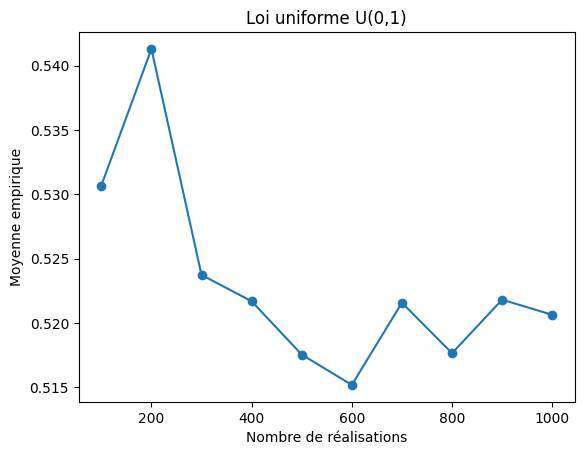

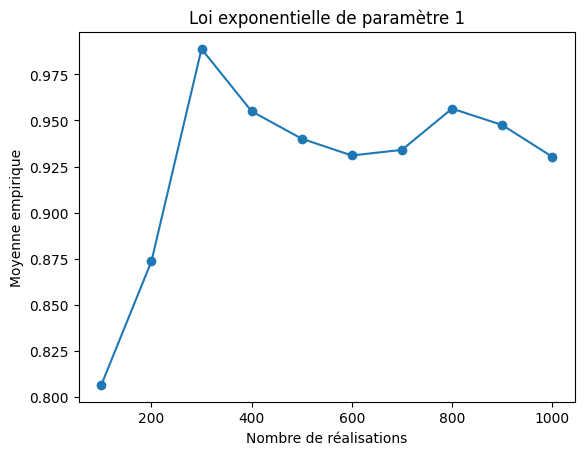

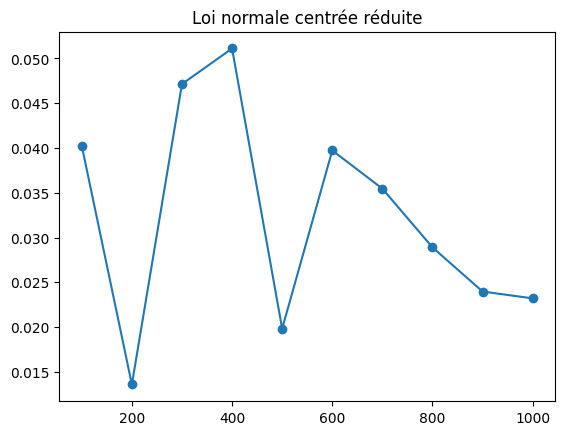

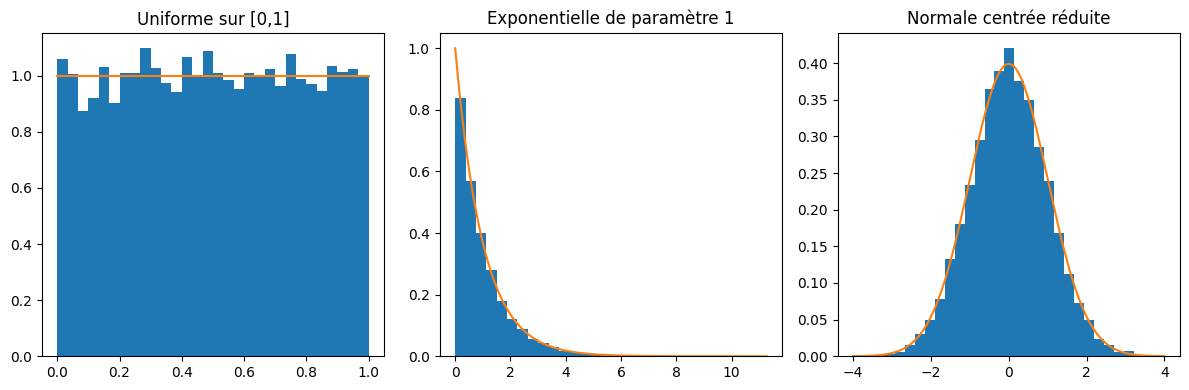

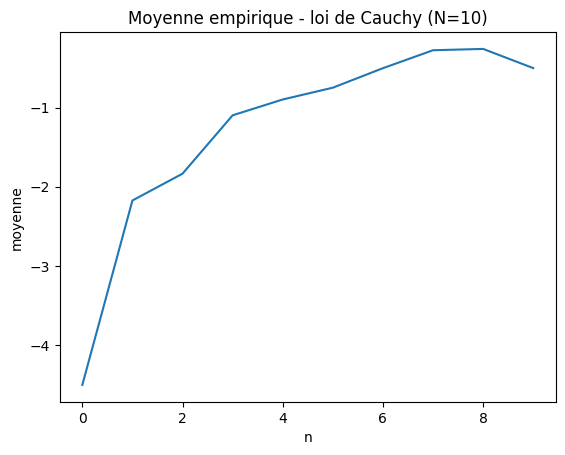

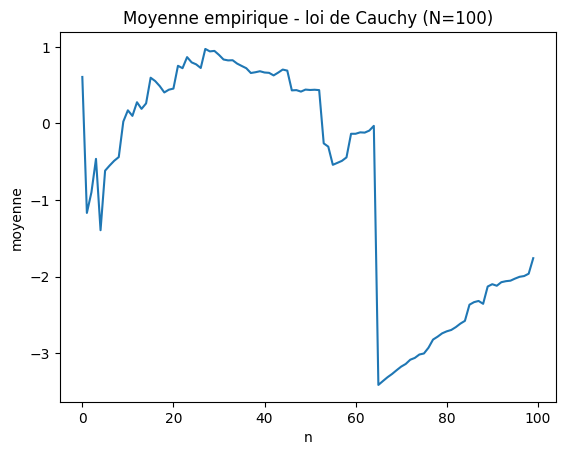

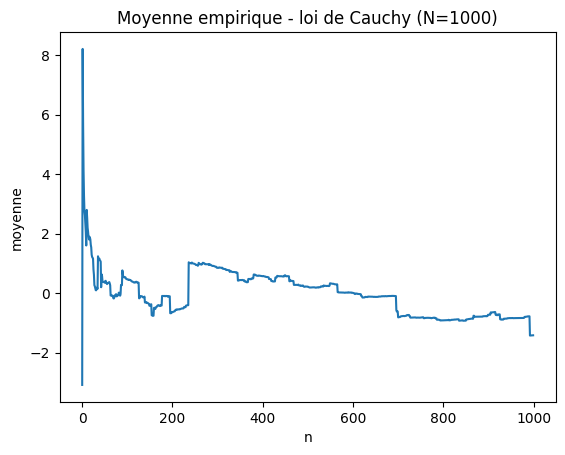

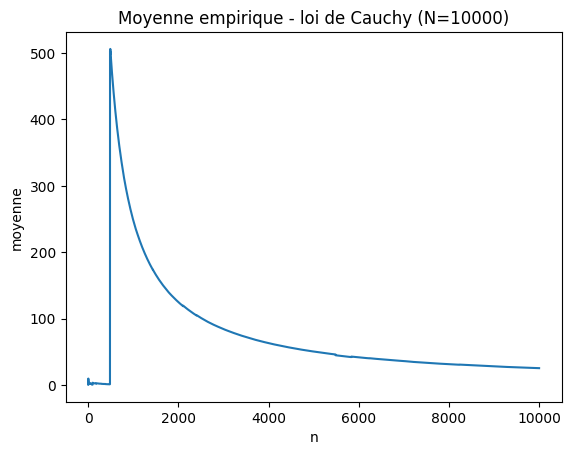

In [ ]:
#1 Simuler les moyennes empiriques version lois uniforme.

U = np.random.rand(1001)
i = np.arange(100,1001,100)
vecteur_U = [np.mean(U[:j]) for j in i]

plt.plot(i, vecteur_U, marker='o')
plt.xlabel("Nombre de réalisations")
plt.ylabel("Moyenne empirique")
plt.title("Loi uniforme U(0,1)")
plt.show()

#2 Simuler les moyennes empiriques version lois exponentielle(1).

U = np.random.exponential(scale=1.0, size=1001)
vecteur_U = [np.mean(U[:j]) for j in i]

plt.plot(i, vecteur_U, marker='o')
plt.xlabel("Nombre de réalisations")
plt.ylabel("Moyenne empirique")
plt.title("Loi exponentielle de paramètre 1")
plt.show()

#3 Simuler les moyennes empiriques version lois normale centrée réduite.

U1 = np.random.rand(1001)
U2 = np.random.rand(1001)
X = np.sqrt(-2*np.log(U1))*np.cos(2*np.pi*U2)

vecteur = [np.mean(X[:j]) for j in i]

plt.plot(i, vecteur, marker='o')
plt.title("Loi normale centrée réduite")
plt.show()

#4 Histogrammes vs densités
N= 10000

U = np.random.rand(N)
X_exp = np.random.exponential(1, N)
X_normal = np.random.randn(N)

axes = plt.subplots(1, 3, figsize=(12,4))[1]

# 1. Loi uniforme
axes[0].hist(U, bins=30, density=True)
x = np.linspace(0,1,100)
axes[0].plot(x, np.ones_like(x))
axes[0].set_title("Uniforme sur [0,1]")

# 2. Loi exponentielle
axes[1].hist(X_exp, bins=30, density=True)
x = np.linspace(0, max(X_exp), 200)
axes[1].plot(x, np.exp(-x))
axes[1].set_title("Exponentielle de paramètre 1")

# 3. Loi normale
axes[2].hist(X_normal, bins=30, density=True)
x = np.linspace(-4,4,200)
axes[2].plot(x, stats.norm.pdf(x,0,1))
axes[2].set_title("Normale centrée réduite")

plt.tight_layout()
plt.show()

#5 Loi de cauchy
for N in [10, 100, 1000, 10000]:
    X = np.random.standard_cauchy(N)
    moyennes = np.cumsum(X) / np.arange(1, N+1)

    plt.plot(moyennes)
    plt.title(f"Moyenne empirique - loi de Cauchy (N={N})")
    plt.xlabel("n")
    plt.ylabel("moyenne")
    plt.show()

#Remarque :
# Contrairement aux autres lois, la moyenne empirique de la loi de Cauchy ne converge pas vers une valeur fixe lorsque N augmente. Cela illustre le fait que la loi de Cauchy n'a pas d'espérance.
# Q :  Quels sont-les moments de la loi de Cauchy qui vont converger grâce à la loi des grands nombres ? Le vérifier numériquement.
# R : Aucun moment de la loi de Cauchy ne converge grâce à la loi des grands nombres, car la loi de Cauchy n'a pas d'espérance. Par conséquent, les moments d'ordre plus grand ne convergent pas non plus.

# 3 Théorème central limite


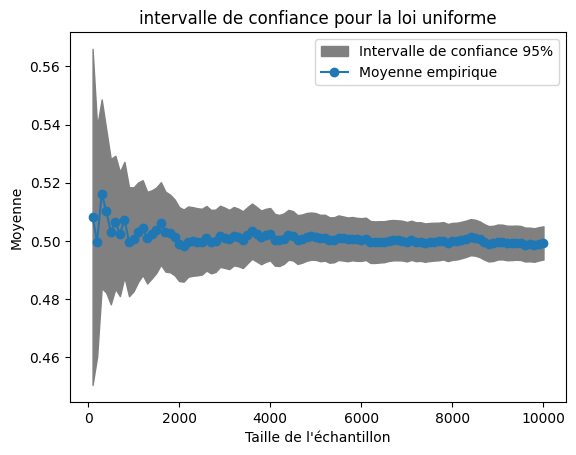

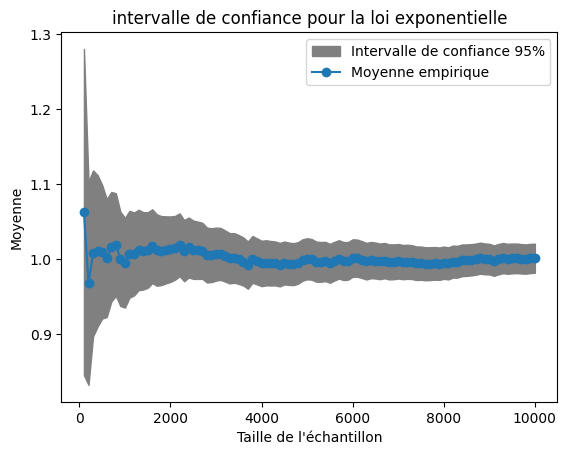

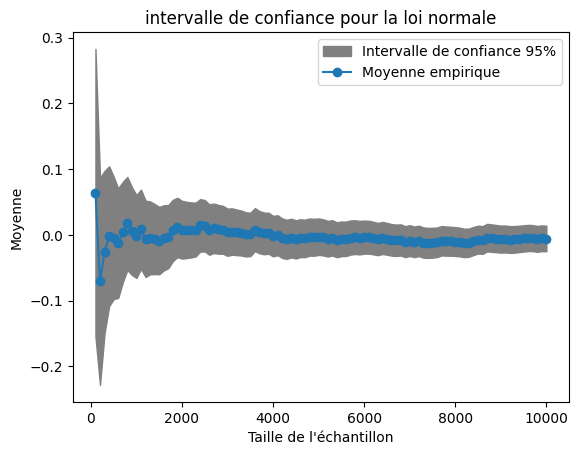

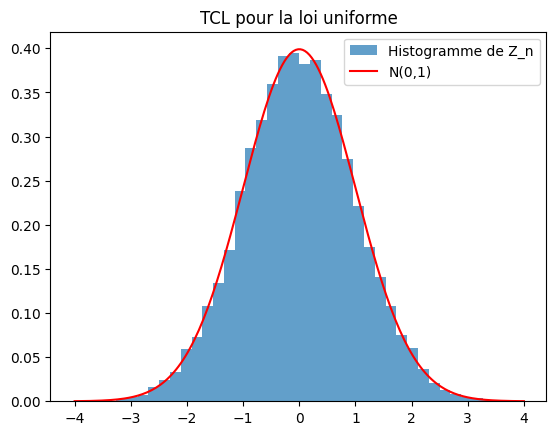

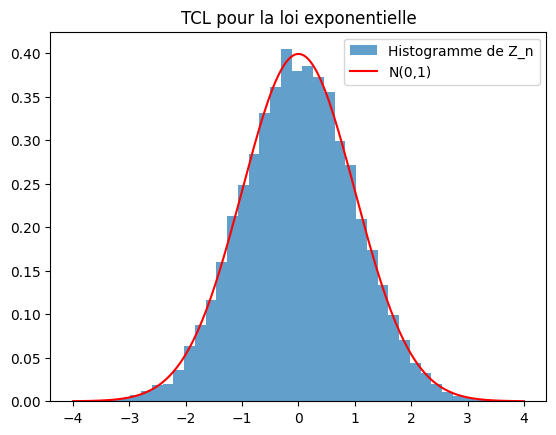

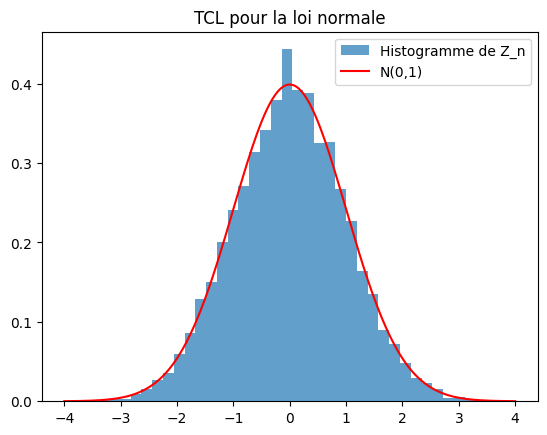

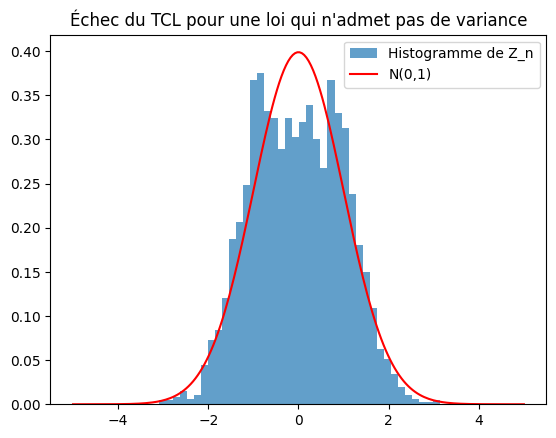

In [27]:
#1 Intervalle de confiance.
from numpy import sqrt
from scipy.integrate import quad
from scipy.stats import norm


a = 0.95
t = 1.96

def intervalle_confiance(X):
    n = len(X)
    mean = np.mean(X)
    sigma = np.std(X, ddof=1)
    h = t * sigma / np.sqrt(n)
    return mean - h, mean + h



N = 10000
tab= np.arange(100, N+1, 100) #Voilà comment j'ai choisis de faire varier le pas du nombre de réalisations considérées.J'ai repris les mêmes conditions que précédemment.
for x in ['uniforme', 'exponentielle', 'normale']:
    if x == 'uniforme':
        X = np.random.rand(N)
        esperance = 0.5
    elif x == 'exponentielle':
        X = np.random.exponential(scale=1.0, size=N)
        esperance = 1.0
    else:
        U1 = np.random.rand(N)
        U2 = np.random.rand(N)
        X = np.sqrt(-2*np.log(U1))*np.cos(2*np.pi*U2)
        esperance = 0.0

    borne_inf = []
    borne_sup = []
    moyenne = []

    for n in tab:
        tmp = X[:n]
        mean = np.mean(tmp)
        moyenne.append(mean)
        bmin, bmax = intervalle_confiance(tmp)
        borne_inf.append(bmin)
        borne_sup.append(bmax)

    plt.fill_between(tab, borne_inf, borne_sup, color='gray', label='Intervalle de confiance 95%')
    plt.plot(tab, moyenne, marker='o', label='Moyenne empirique')
    plt.title("intervalle de confiance pour la loi " + str(x))
    plt.xlabel("Taille de l'échantillon")
    plt.ylabel("Moyenne")
    plt.legend()
    plt.show()



#2 vérification du TCL.

nb_realisations = 15000
for loi in ["uniforme", "exponentielle", "normale"]:
    Zn = []

    for _ in range(nb_realisations):
        if loi == "uniforme":
            X = np.random.rand(n)
            m = 0.5
        elif loi == "exponentielle":
            X = np.random.exponential(1, n)
            m = 1
        else:  # normale
            X = np.random.randn(n)
            m = 0

        x_hat = np.mean(X)
        sigma_hat = np.std(X, ddof=1)

        Zn.append(np.sqrt(n) * (x_hat - m) / sigma_hat)

    # Histogramme du TCL
    plt.hist(Zn, bins=40, density=True, alpha=0.7, label="Histogramme de Z_n")

    x = np.linspace(-4, 4, 200)
    plt.plot(x, norm.pdf(x), 'r', label="N(0,1)")

    plt.title("TCL pour la loi " + loi)
    plt.legend()
    plt.show()


#3 Test pour une variable qui n'est pas de carré intégrable.
# on s'attend à ce que Zn ne suive pas une loi normale centrée réduite ou ne converge pas en tant donnée que la condition du TCL n'est pas satisfaite.

beta = 2.5
n = 1000
M = 3000

# Calcul de C_beta
I, _ = quad(lambda x: 1/(1+abs(x)**beta), -np.inf, np.inf)
C_beta = 1/I

def f(x):
    return C_beta/(1+np.abs(x)**beta)

def g(x):
    return 1/(np.pi*(1+x**2))

C = 5  # constante de rejet

def tirage_beta(size):
    res = []
    while len(res) < size:
        Y = np.random.standard_cauchy()
        U = np.random.rand()
        if U < f(Y)/(C*g(Y)):
            res.append(Y)
    return np.array(res)

Z = []

for _ in range(M):
    X = tirage_beta(n)
    m = np.mean(X)
    sigma_hat = np.std(X, ddof=1)
    Z.append(np.sqrt(n)*(m)/sigma_hat)

plt.hist(Z, bins=40, density=True, alpha=0.7, label="Histogramme de Z_n")
x = np.linspace(-5,5,200)
plt.plot(x, norm.pdf(x), 'r', label="N(0,1)")
plt.title("Échec du TCL pour une loi qui n'admet pas de variance")
plt.legend()
plt.show()

#Comme prévu, la distribution de Zn ne ressemble pas à une loi normale centrée réduite.

# 4 Méthode de Monte Carlo

l'approche probabiliste est que pour chaque intégrale de la reformuler chaque intégrale comme une espérance d'une uniforme.

pour la première intégrale :

![](image1.png)

pour la deuxième :

![](im2.png)

et finalement pour la 3ieme :

![](i3.png)

# 5 Méthode du rejet

Pas de question.

# 6 Lois mélanges

#1 preuve de la proposition : 

![](p.png)

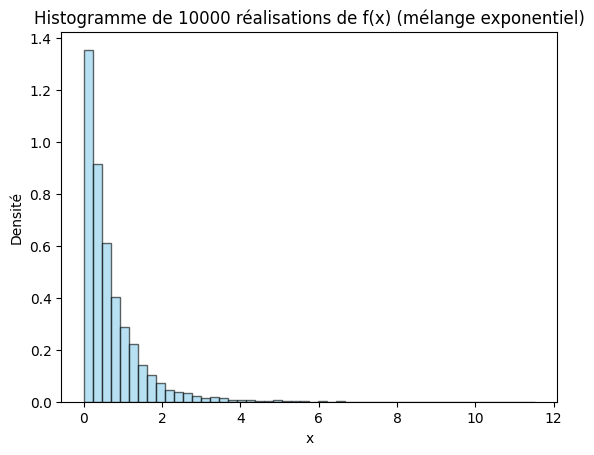

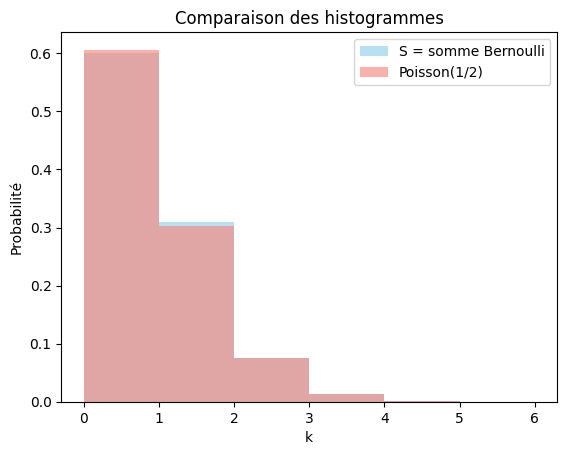

In [3]:
n = 10000

#2
indices = np.random.choice([1,2], size=n, p=[1/3, 2/3])
X = np.where(indices == 1, np.random.exponential(scale=1, size=n),np.random.exponential(scale=0.5, size=n))

plt.hist(X, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black')
plt.title("Histogramme de 10000 réalisations de f(x) (mélange exponentiel)")
plt.xlabel("x")
plt.ylabel("Densité")
plt.show()

#3
N = np.random.poisson(lam=1, size=n)
S = np.array([np.sum(np.random.binomial(1,0.5,size=k)) for k in N])

somme = np.random.poisson(lam=0.5, size=n)

plt.hist(S, bins=range(0, max(max(S), max(somme))+2), density=True, alpha=0.6, color='skyblue', label='S = somme Bernoulli')
plt.hist(somme, bins=range(0, max(max(S), max(somme))+2), density=True, alpha=0.6, color='salmon', label='Poisson(1/2)')
plt.legend()
plt.title("Comparaison des histogrammes")
plt.xlabel("k")
plt.ylabel("Probabilité")
plt.show()